# Phsycial Basis of Sea Surface Salinity Measurements

Sea surface salinity (SSS) is a major indicator of physical ocean processes including precipitation, evaporation, runoff, advection, upwelling, diffusion, and sea ice formation. Satellites estimate SSS by measuring small changes in microwave emission from the ocean surface, especially near the **L-band** frequency of 1.413 GHz.

## Learning objectives

By the end of this notebook, you should be able to:

1. Explain the physical basis of SSS satellite products and their limitations.
2. List the major satellite missions used for SSS observations.
3. Explain how SSS products are derived from microwave measurements.
4. Describe the major correction terms needed to retrieve SSS from brightness temperature.

## Imports

We will use `numpy` for calculations, `pandas` for tabular summaries, and `matplotlib` for simple plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,
})

# Part 1: The Physical Basis for SSS Products

## What is sea surface salinity?

Ocean salinity is determined by dissolved salts in seawater. These salts dissolve into ions, which alter the electrical properties of seawater. Since electromagnetic radiation interacts with charged particles and polar molecules, changes in salinity affect the microwave radiation emitted by the ocean surface.

The key physical chain is:

\[
\text{salinity} \rightarrow \text{dielectric constant} \rightarrow \text{emissivity} \rightarrow \text{brightness temperature}
\]

Satellite SSS retrievals are based on detecting small changes in microwave brightness temperature associated with salinity-driven changes in emissivity.

## Brightness temperature

Planck's Law relates the radiation emitted by a blackbody to its physical temperature and wavelength. For real surfaces such as the ocean, emission is modified by the surface emissivity.

**Brightness temperature**, usually written as \(T_B\), is the temperature a blackbody would need to have in order to emit the observed radiance at a given wavelength or frequency.

For a simple ocean surface approximation:

\[
T_B = e \, T_S
\]

where:

- \(T_B\) is brightness temperature,
- \(e\) is emissivity, and
- \(T_S\) is the physical sea surface temperature.

For the ocean, emissivity is not constant. It depends on frequency, temperature, salinity, polarization, viewing angle, and surface roughness.

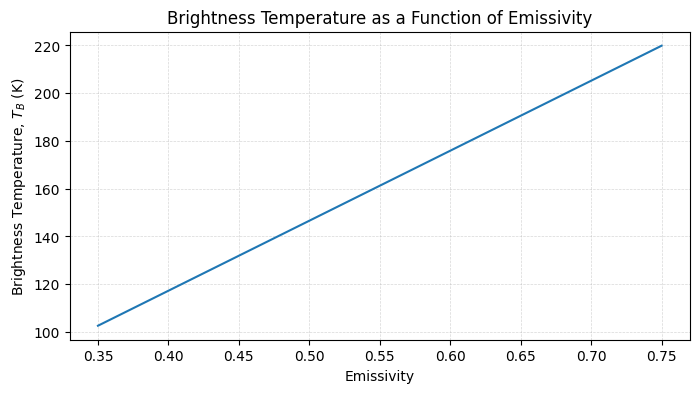

In [2]:
# A simple demonstration of brightness temperature
# This is not a full SSS retrieval model. It only shows how emissivity modifies observed temperature.

Ts = 293.15  # sea surface temperature in K, equivalent to 20 deg C
emissivities = np.linspace(0.35, 0.75, 100)
Tb = emissivities * Ts

plt.plot(emissivities, Tb)
plt.xlabel('Emissivity')
plt.ylabel('Brightness Temperature, $T_B$ (K)')
plt.title('Brightness Temperature as a Function of Emissivity')
plt.show()

## Water's dielectric constant

The dielectric constant, also called relative permittivity, describes how a material responds to an electric field. Pure water has a high dielectric constant because water molecules are strongly polar. Adding dissolved salt changes the electrical properties of the water and decreases the dielectric constant.

In practice, satellite algorithms use laboratory-based models of seawater dielectric properties. The retrieval is sensitive to these models because the change in brightness temperature caused by salinity is small.

Important dependencies include:

- salinity,
- temperature,
- frequency,
- polarization, and
- viewing angle.

## The microwave spectrum and the L-band

Microwave radiation spans wavelengths of approximately 1 mm to 1 m, corresponding to frequencies from roughly 300 GHz down to 300 MHz.

Satellite SSS retrievals use the **L-band**, near 1.4 GHz, because brightness temperature at this frequency is especially sensitive to salinity and because this portion of the spectrum is protected for passive Earth observations.

The relationship between frequency and wavelength is:

\[
\lambda = \frac{c}{f}
\]

where \(c\) is the speed of light and \(f\) is frequency.

In [3]:
# Compute the wavelength of the L-band radiometer frequency used for SSS
c = 2.9979e8      # speed of light, m/s
f_lband = 1.413e9 # L-band radiometer frequency, Hz
lambda_lband = c / f_lband

print(f'L-band frequency: {f_lband/1e9:.3f} GHz')
print(f'L-band wavelength: {lambda_lband:.3f} m')
print(f'L-band wavelength: {lambda_lband*100:.1f} cm')

L-band frequency: 1.413 GHz
L-band wavelength: 0.212 m
L-band wavelength: 21.2 cm


### Check your understanding

Microwave ovens operate at approximately 2.45 GHz.

1. What is the wavelength of radiation in a microwave oven?
2. Which microwave band does this correspond to?

In [4]:
# Wavelength of radiation in a microwave oven
f_oven = 2.45e9
lambda_oven = c / f_oven

print(f'Microwave oven frequency: {f_oven/1e9:.2f} GHz')
print(f'Microwave oven wavelength: {lambda_oven:.3f} m')
print(f'Microwave oven wavelength: {lambda_oven*100:.1f} cm')

Microwave oven frequency: 2.45 GHz
Microwave oven wavelength: 0.122 m
Microwave oven wavelength: 12.2 cm


## Microwave band designations

Microwave bands are historical letter designations. The exact boundaries vary somewhat by convention, but the table below summarizes the bands emphasized in this lesson.

In [5]:
bands = pd.DataFrame({
    'Band': ['L', 'S', 'C', 'X', 'Ku'],
    'Approximate Wavelength Range': ['15 cm - 30 m', '7.5 cm - 15 cm', '3.75 cm - 7.5 cm', '25 mm - 37.5 mm', '16.7 mm - 25 mm'],
    'Example Uses': ['GPS, mobile phones, SSS radiometry', 'weather radar, ship radar', 'long-distance radio', 'satellite communications, spectroscopy', 'satellite communications']
})
bands

,Band,Approximate Wavelength Range,Example Uses
0,L,15 cm - 30 m,"GPS, mobile phones, SSS radiometry"
1,S,7.5 cm - 15 cm,"weather radar, ship radar"
2,C,3.75 cm - 7.5 cm,long-distance radio
3,X,25 mm - 37.5 mm,"satellite communications, spectroscopy"
4,Ku,16.7 mm - 25 mm,satellite communications


## Why SSS is difficult to retrieve

The satellite is not directly measuring salinity. It is measuring brightness temperature. Salinity is inferred after accounting for many other factors that also influence microwave emission.

A simplified retrieval concept is:

\[
T_B^{obs} = T_B^{ocean} + T_B^{atm} + T_B^{space/reflection} + T_B^{ionosphere} + \epsilon
\]

The desired ocean term depends on sea surface temperature and emissivity:

\[
T_B^{ocean} = e(f, T, S, \theta, p, \text{roughness})T_S
\]

where \(f\) is frequency, \(T\) is temperature, \(S\) is salinity, \(\theta\) is look angle, and \(p\) is polarization.

Because the salinity signal is small, retrievals require careful correction for atmosphere, surface roughness, solar reflection, ionospheric effects, and land or sea ice contamination.

## Temperature sensitivity

At L-band, brightness temperature is more sensitive to salinity changes in warm water than in cold water. In cold polar regions, the slope of brightness temperature versus salinity is small, so very precise measurements are needed to estimate salinity accurately.

The following plot is a conceptual illustration of this idea. It is not a full dielectric model.

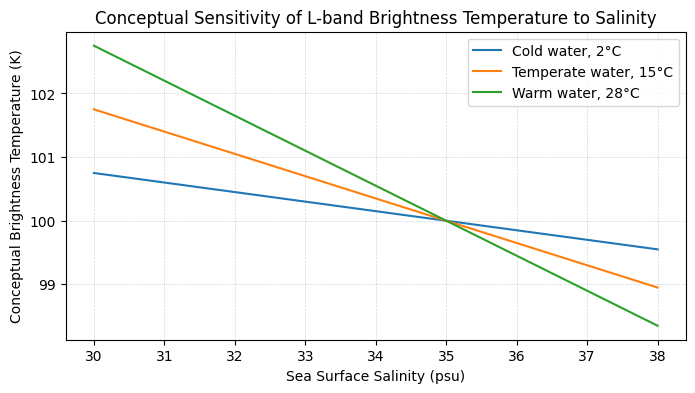

In [6]:
# Conceptual sensitivity of TB to salinity at different temperatures
salinity = np.linspace(30, 38, 100)
S0 = 35

# Conceptual slopes in K/psu: larger for warm water, smaller for cold water
slopes = {
    'Cold water, 2°C': -0.15,
    'Temperate water, 15°C': -0.35,
    'Warm water, 28°C': -0.55,
}

for label, slope in slopes.items():
    Tb_conceptual = 100 + slope * (salinity - S0)
    plt.plot(salinity, Tb_conceptual, label=label)

plt.xlabel('Sea Surface Salinity (psu)')
plt.ylabel('Conceptual Brightness Temperature (K)')
plt.title('Conceptual Sensitivity of L-band Brightness Temperature to Salinity')
plt.legend()
plt.show()

## SSS sampling depth

The microwave emission used for SSS retrievals comes from only the very top of the ocean, typically the upper few millimeters. However, the term **skin SSS** is not commonly used in the same way as skin SST.

This matters because:

- satellite SSS samples the near-surface layer,
- Argo floats and other in situ measurements often sample deeper water,
- rainfall, evaporation, wind mixing, and stratification can create vertical salinity gradients near the surface.